In [2]:
# pip install tensorflow
# pip install onnx
# pip install torch torchvision

In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cpu'

In [75]:
# Step 5: Define the CNN model for MNIST classification
from torch import nn

class MNIST_model (nn.Module):
    def __init__(self, 
                input_shape:int,
                hidden_units:int,
                output_shape:int):
        super().__init__()
        
        # First convolutional block
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                    out_channels= hidden_units,
                    kernel_size= 3),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Second convolutional block
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                    out_channels= hidden_units,
                    kernel_size= 3),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Calculate the flattened feature size after conv blocks
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_shape, 28, 28)
            x = self.block_1(dummy_input)
            x = self.block_2(x)
            num_features = x.shape[1] * x.shape[2] * x.shape[3]
            
        # Classifier (fully connected layer)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features= num_features,
                out_features= output_shape
            )
        )
        
    def forward (self, x:torch.Tensor):
        # Forward pass through conv blocks and classifier
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        
        return x
    

# Instantiate the model
model = MNIST_model(input_shape=1,
                    hidden_units=32,
                    output_shape=10)

model, model.state_dict()

(MNIST_model(
   (block_1): Sequential(
     (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
     (1): ReLU()
     (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (block_2): Sequential(
     (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
     (1): ReLU()
     (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=512, out_features=10, bias=True)
   )
 ),
 OrderedDict([('block_1.0.weight',
               tensor([[[[ 0.2368,  0.1139, -0.2473],
                         [-0.1681, -0.0628, -0.0574],
                         [ 0.0023, -0.2116, -0.1059]]],
               
               
                       [[[ 0.1283,  0.2822, -0.1506],
                   

In [77]:
# Load the model
model.load_state_dict(torch.load(f="MNIST_Model.pth"))

model, model.state_dict()

(MNIST_model(
   (block_1): Sequential(
     (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
     (1): ReLU()
     (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (block_2): Sequential(
     (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
     (1): ReLU()
     (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=512, out_features=10, bias=True)
   )
 ),
 OrderedDict([('block_1.0.weight',
               tensor([[[[ 1.3035e-01,  2.1268e-01,  3.1478e-01],
                         [-6.8251e-02, -1.0342e-01,  5.3528e-02],
                         [-1.9485e-01, -7.9916e-02,  2.0844e-01]]],
               
               
                       [[[ 1.7454e-01

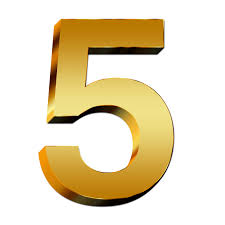

torch.Size([1, 28, 28])
torch.Size([1, 1, 28, 28])
tensor([[-0.0446, -2.5804, -0.2036,  0.2411, -1.4684,  1.9327, -2.4295,  0.5403,
          1.8176,  1.5236]])
tensor([5])


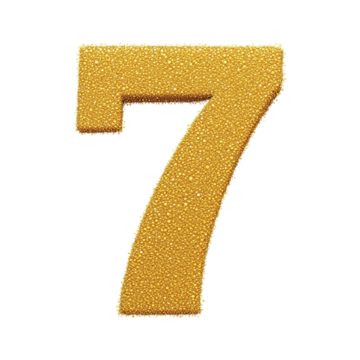

torch.Size([1, 28, 28])
torch.Size([1, 1, 28, 28])
tensor([[-1.7846,  3.5339,  3.3356,  1.9516, -3.7122, -2.8363, -2.6873,  2.4926,
          1.5185, -2.2599]])
tensor([1])


In [83]:
from IPython.display import display
import numpy as np
from PIL import Image
import tensorflow as tf
from torchvision import transforms, io

# Load and display the sample images
image_paths = ['testing_data/image1.png', 'testing_data/image2.png'] # Replace with the paths to your own images

for image_path in image_paths:
    image = Image.open(image_path)
    display(image)

    # Preprocess the image
    image = io.read_image(image_path).type(torch.float32)
    image /= 255

    # Remove alpha channel if present (keep only first 3 channels)
    if image.shape[0] == 4:
        image = image[:3, :, :]

    trans = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((28, 28))
    ])

    image = trans(image)
    print(image.shape)
    
    model.eval()
    with torch.inference_mode():
        image = image.unsqueeze(dim=0)
        print(image.shape)
        output = model(image)
        print(output)
        print(output.argmax(dim=1))

In [84]:
import torch
import torch.onnx as onnx

# Specify the input size and data type
input_size = (1,1,28,28)
dummy = torch.randn(input_size).to(device)
data_type = torch.float32

# Convert the PyTorch model to ONNX
ONNX_MODEL_PATH = "MNIST_Model.onnx"
onnx.export(model, 
            dummy, 
            ONNX_MODEL_PATH, 
            opset_version=11, 
            input_names=['input'], output_names=['output'], 
            dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})

print("PyTorch model converted to ONNX and saved as", ONNX_MODEL_PATH)

PyTorch model converted to ONNX and saved as MNIST_Model.onnx


In [85]:
import tensorflow as tf
import onnx
from PIL import Image
import numpy as np

In [86]:
import onnx
from onnx_tf.backend import prepare

# Load the ONNX model
onnx_model = onnx.load(ONNX_MODEL_PATH)

# Convert the ONNX model to a TensorFlow representation
tf_rep = prepare(onnx_model)

# Access the raw TensorFlow model if needed
tf_model = tf_rep.tf_module

# Export the model as a TensorFlow SavedModel
tf_rep.export_graph("tensorflow_model")

print("✅ ONNX model successfully imported and saved as TensorFlow SavedModel.")


INFO:tensorflow:Assets written to: tensorflow_model\assets


INFO:tensorflow:Assets written to: tensorflow_model\assets


✅ ONNX model successfully imported and saved as TensorFlow SavedModel.


In [87]:
from PIL import Image
import numpy as np

# Load and display the sample images
image_paths = ['testing_data/image1.png', 'testing_data/image2.png'] # Replace with the paths to your own images

image = Image.open(image_paths[0]).resize((28, 28), Image.Resampling.LANCZOS)
image = np.array(image.convert('L')).astype(np.float32) / 255.0  # shape: (28, 28)
image = image.reshape(1, 1, 28, 28)  # shape: (1, 1, 28, 28)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print(tf_rep.inputs)



output = tf_rep.run({"input": image})  # <-- Make sure to use a dict if needed!
predicted_label = np.argmax(output)

print("Predicted label:", predicted_label)


Image shape: (1, 1, 28, 28)
Image dtype: float32
['input']
Predicted label: 8


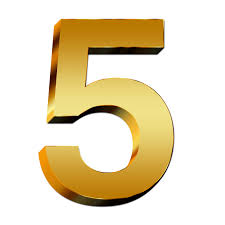

Outputs(output=array([[-0.0849418 , -2.5333264 , -0.09379817,  0.29770076, -1.4999723 ,
         1.7565013 , -2.7396297 ,  0.85827893,  1.7660547 ,  1.5468162 ]],
      dtype=float32))
Predicted label: 8


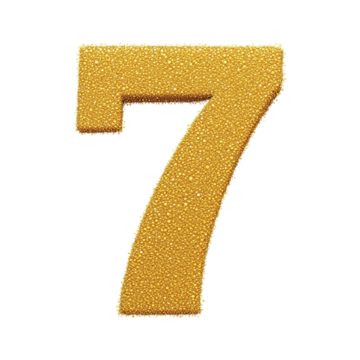

Outputs(output=array([[ 0.2250869 ,  1.3857224 ,  2.109862  ,  1.6447679 , -2.543668  ,
        -1.0115039 , -0.44509274, -1.0412836 ,  2.850758  , -4.0853047 ]],
      dtype=float32))
Predicted label: 8


In [88]:
from IPython.display import display
import numpy as np
from PIL import Image
import tensorflow as tf

# Load and display the sample images
image_paths = ['testing_data/image1.png', 'testing_data/image2.png'] # Replace with the paths to your own images

for image_path in image_paths:
    image = Image.open(image_path)
    display(image)

    # Preprocess the image
    image = image.resize((28, 28), Image.Resampling.LANCZOS)
    image = np.array(image.convert('L')).astype(np.float32) / 255.0  # shape: (28, 28)
    image = image.reshape(1, 1, 28, 28)  # shape: (1, 1, 28, 28)

    # display(image)
    
    # Perform the prediction using tf_rep
    output = tf_rep.run(image)
    print(output)
    predicted_label = np.argmax(output)

    print("Predicted label:", predicted_label)